In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(f"Columns: {list(df.columns)}")

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df['Age']=df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df=df.dropna(subset=['Embarked'])
df.isnull().sum()#checking

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [8]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(f"Columns: {list(df.columns)}")

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize']


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize  Sex_encoded  
0      0         A/5 21171   7.2500        S           2            1  
1      0          PC 17599  71.2833        C           2            0  
2      0  STON/O2. 3101282   7.9250        S           1            0  
3      0            113803  53.1

In [10]:

X = df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize']]
y = df['Survived']

print(X.shape)
print(y.shape)

(889, 5)
(889,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(711, 5) (178, 5)
(711,) (178,)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Create model
model = LogisticRegression(max_iter=1000)

# 2. Train model
model.fit(X_train, y_train)

# 3. Make predictions
y_pred = model.predict(X_test)

# 4. Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 79.21%


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Create model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train model
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

Random Forest Accuracy: 79.21%


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.85      0.81      0.83       109
           1       0.72      0.77      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



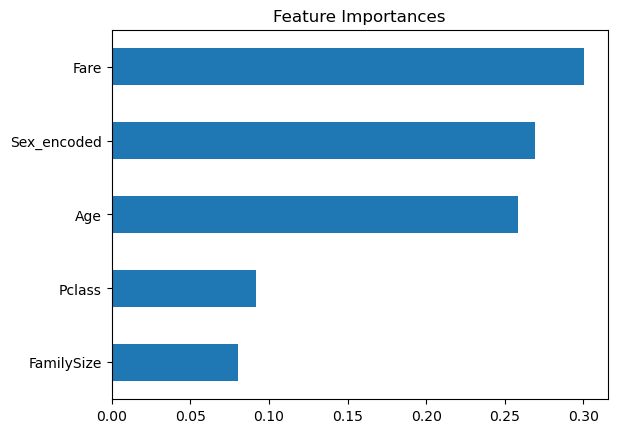

In [23]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize']
)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [25]:
print(importances.sort_values(ascending=False))

Fare           0.300360
Sex_encoded    0.269515
Age            0.258213
Pclass         0.091594
FamilySize     0.080317
dtype: float64


In [26]:
passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex_encoded': [1],  # male
    'Age': [22],
    'Fare': [7.25],
    'FamilySize': [1]
})

prediction = rf_model.predict(passenger)
probability = rf_model.predict_proba(passenger)

print(f"Prediction: {'Survived' if prediction[0]==1 else 'Died'}")
print(f"Survival probability: {probability[0][1]:.2%}")

Prediction: Died
Survival probability: 1.00%


In [28]:
passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex_encoded': [0],  # female
    'Age': [30],
    'Fare': [100],
    'FamilySize': [2]
})

prediction = rf_model.predict(passenger)
probability = rf_model.predict_proba(passenger)

print(f"Prediction: {'Survived' if prediction[0]==1 else 'Died'}")
print(f"Survival probability: {probability[0][1]:.2%}")

Prediction: Survived
Survival probability: 100.00%


In [30]:
passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex_encoded': [1],  # male
    'Age': [25],
    'Fare': [7],
    'FamilySize': [1]
})

prediction = rf_model.predict(passenger)
probability = rf_model.predict_proba(passenger)

print(f"Prediction: {'Survived' if prediction[0]==1 else 'Died'}")
print(f"Survival probability: {probability[0][1]:.2%}")

Prediction: Died
Survival probability: 9.00%


Experiments

In [31]:
X_no_sex = df[['Pclass', 'Age', 'Fare', 'FamilySize']]
y = df['Survived']
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Create model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train model
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

Random Forest Accuracy: 79.21%


In [33]:
me = pd.DataFrame({
    'Pclass': [2],        # 1, 2, or 3 — your choice
    'Sex_encoded': [0],   # 0=female, 1=male
    'Age': [22],           # your actual age
    'Fare': [10],          # pick a fare
    'FamilySize': [3]     # how many family members + yourself
})

prediction = rf_model.predict(me)
probability = rf_model.predict_proba(me)

print(f"Prediction: {'Survived' if prediction[0]==1 else 'Died'}")
print(f"Survival probability: {probability[0][1]:.2%}")

Prediction: Survived
Survival probability: 94.00%
